In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import torch


In [2]:
# grid

dx = 0.02
x = torch.arange(0, 10, dx, dtype=torch.float64)


In [3]:

N = len(x)


D2 = torch.zeros((N, N), dtype=torch.complex128)

for i in range(N):

    D2[i, i] = -2.0

    if i > 0:
        D2[i, i - 1] = 1.0

    if i < N - 1:
        D2[i, i + 1] = 1.0

D2 = D2 / (dx**2)

In [4]:

sigma = torch.tensor(0.1, dtype=torch.float64)

m = torch.tensor(1.0, dtype=torch.float64)

x0 = torch.tensor(3.0, dtype=torch.float64)

kx = torch.tensor(0.1, dtype=torch.float64)

hbar = torch.tensor(1.0, dtype=torch.float64)

A = 1.0 / (sigma * torch.sqrt(torch.tensor(np.pi, dtype=torch.float64)))


In [5]:
dt = 0.0003

timesteps = 5000

save_every = 100

In [6]:

def f(psi, omega):

    x_Vmin = torch.tensor(5.0, dtype=torch.float64)
    k = omega**2 * m
    V = 0.5 * k * (x - x_Vmin)**2

    #lap = D2 @ psi

    lap = (
        torch.roll(psi, -1)
        - 2 * psi
        + torch.roll(psi, 1)
    ) / dx**2

    return -1j * (-0.5 * hbar / m * lap + (V / hbar) * psi)

In [7]:
def rk4_step(state, omega):

    k1 = f(state, omega)

    k2_state = state + 0.5 * dt * k1
    k2 = f(k2_state, omega)

    k3_state = state + 0.5 * dt * k2
    k3 = f(k3_state, omega)

    k4_state = state + dt * k3
    k4 = f(k4_state, omega)

    return state + (dt / 6.0) * (
        k1 + 2*k2 + 2*k3 + k4
    )

In [ ]:
def solver(omega):

    psi0 = (
        torch.sqrt(A)
        *
        torch.exp(
            -(x - x0)**2 / (2.0 * sigma**2)
        )
        *
        torch.exp(
            (1j * kx * x).to(torch.complex128)
        )
    ).to(torch.complex128)

    psi = psi0.clone()

    psi_array = [psi.clone()]

    for i in range(timesteps):

        if i % save_every == 0:
            psi_array.append(psi.clone())

        psi = rk4_step(psi, omega)

    return torch.stack(psi_array)

In [9]:


omega_true = torch.tensor(
    2 * np.pi,
    dtype=torch.float64
)

with torch.no_grad():

    true_values = solver(omega_true)

In [10]:

def calculate_loss(omega):

    predictions = solver(omega)
    loss = torch.mean((torch.abs(predictions)**2 - torch.abs(true_values)**2)**2)

    return loss

In [11]:

omega = torch.tensor(5.0, dtype=torch.float64, requires_grad=True)

optimizer = torch.optim.Adam(
    [omega],
    lr=0.1
)



In [12]:

epochs = 40

for epoch in range(epochs):

    optimizer.zero_grad()
    loss = calculate_loss(omega)
    loss.backward()
    optimizer.step()

    print(
        epoch,
        omega.item(),
        loss.item()
    )

0 4.900000034591484 0.06380957819280263
1 4.871959294719381 0.0647081518840171
2 4.83756512899774 0.06464377484615551
3 4.874760575623063 0.06538102110990454
4 4.899445975652286 0.06466485465837117
5 4.930108127034646 0.06471559780635978
6 4.9816339672785155 0.06357252649258849
7 5.00413672120661 0.06314989579876669
8 5.012478074579791 0.06391500053081346
9 5.018992423648571 0.06401785982595846
10 5.033361994636786 0.06396845591189526
11 5.069791175472706 0.06340092482017713
12 5.123000354242568 0.0604948894688353
13 5.171938874977131 0.05915765065044937
14 5.23223135253404 0.057534534532717015
15 5.278774729872234 0.0563642644432329
16 5.333468137973455 0.056501128518145254
17 5.399202389961515 0.05204106431877374
18 5.4648795764797455 0.050074001048646094
19 5.5359157110603725 0.046438796078720625
20 5.602223228553701 0.04591860199075499
21 5.6802406048546015 0.04137118725743683
22 5.757533381173675 0.03699213271233152
23 5.8414283023778575 0.03224281064117717
24 5.922616489859738 0.

In [13]:
pred_results = solver(omega)


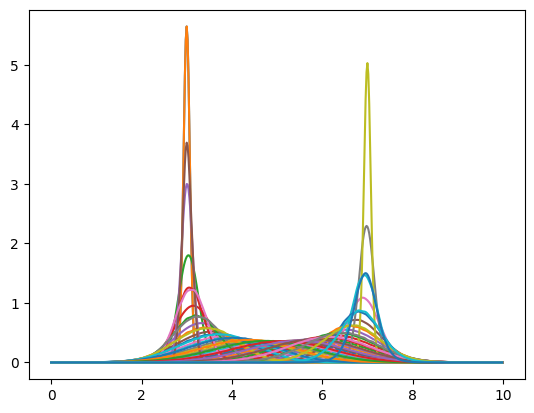

In [14]:
import matplotlib.pyplot as plt

for i in range(len(true_values)):
    plt.plot(x, np.abs(true_values[i].detach().numpy())**2)

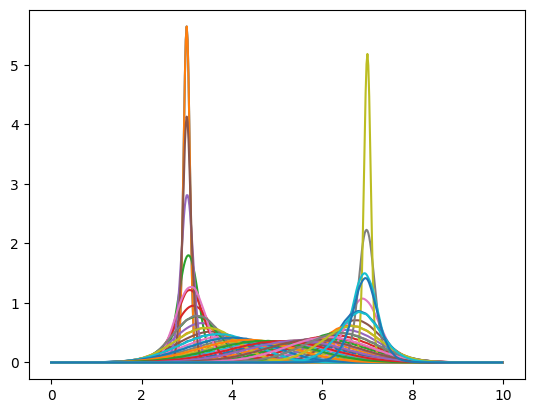

In [15]:


for i in range(len(pred_results)):
    plt.plot(x, np.abs(pred_results[i].detach().numpy())**2)


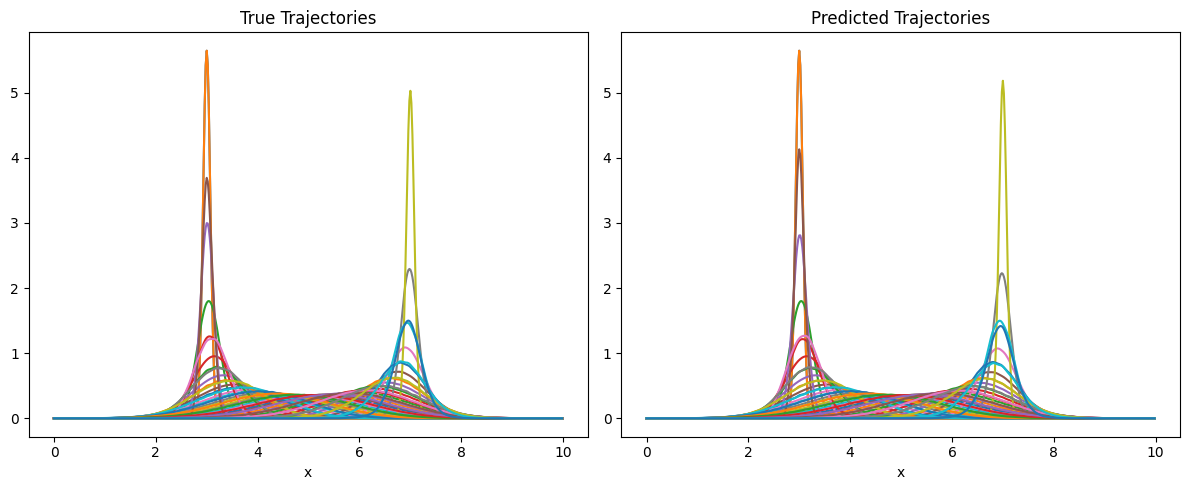

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ============================================================
# TRUE VALUES
# ============================================================

for i in range(len(true_values)):

    axes[0].plot(
        x.detach().numpy(),
        np.abs(
            true_values[i].detach().numpy()
        )**2
    )

axes[0].set_title("True Trajectories")
axes[0].set_xlabel("x")


# ============================================================
# PREDICTED VALUES
# ============================================================

for i in range(len(pred_results)):

    axes[1].plot(
        x.detach().numpy(),
        np.abs(
            pred_results[i].detach().numpy()
        )**2
    )

axes[1].set_title("Predicted Trajectories")
axes[1].set_xlabel("x")


plt.tight_layout()

plt.show()